# Visualize Data with Seaborn

This tutorial shows common charts made with the Seaborn and Matplotlib libraries.

**Outcomes**:
- Create a bar plot
- Create a count plot
- Create a histogram
- Create a box plot
- Create a scatter plot
- Create a pair plot
- Customize chart titles and axis labels
- Change chart styles and color palettes
- Use pre-built code to quickly visualize a dataset

**Links:**
- [template](template.ipynb)

**Optional Reading**
- [Handbook: Seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html)

## Before you start

Every example needs these imports, and every chart ends with `plt.show()`:

```python
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
```

Seaborn draws the chart; Matplotlib controls the surrounding furniture — the title, the axis labels, the figure size. That division explains why almost every example mixes `sns.` and `plt.` calls.

Seaborn also ships with practice datasets, so you can try any chart without supplying data:

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_penguins = sns.load_dataset("penguins")
print(df_penguins.shape)      # should print (344, 7)
print(df_penguins.head())       # should print the first 5 rows of the dataset

(344, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


## Choosing a chart

The chart follows from the data types in the earlier module. Match the number and kind of variables, and the choice usually makes itself.

| What you have | Chart | Question it answers |
|---|---|---|
| One categorical | Count plot | How many in each group? |
| One quantitative | Histogram | How is it distributed? |
| One categorical + one quantitative | Bar plot | What is the average per group? |
| One categorical + one quantitative | Box or violin plot | How does the *spread* differ per group? |
| Two quantitative | Scatter plot | Are they related? |
| Two quantitative + time | Line plot | How has it changed? |
| Many quantitative | Pair plot | Which pairs are worth a closer look? |

The bar-versus-box decision is the one students get wrong most often. A bar plot collapses each group to a single number and hides everything else. A box plot shows the median, the spread, and the outliers. If the question is about variation, the bar plot has already thrown away your answer.


## Bar Plot

Use *bar* plots to compare means or medians across categories.

Required:

- `data = dataframe`: your dataset
- `x = 'fieldname of category'`: categorical variable
- `y = 'fieldname of quantitative'`: quantitative variable (or switch to x for a horizontal bar plot)

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each bar
- `estimator = np.mean`: function to compute the value to be plotted (default is mean, but you can use np.median, np.sum, etc.)
- `errorbar = ('ci', 95)`: confidence interval for the estimate (default is 95%)


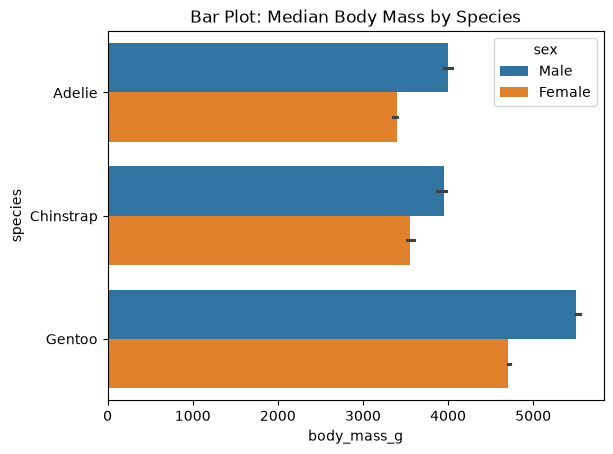

In [15]:
# Barplot Example
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_penguins = sns.load_dataset("penguins")

# Bar plot: median body mass by species
sns.barplot(data=df_penguins, y="species", x="body_mass_g", hue="sex", errorbar = ('ci', 50), estimator=np.median)
plt.title("Bar Plot: Median Body Mass by Species")
plt.show()


### What the bar actually shows

Each bar is **one number** — an aggregate of many rows — not a raw value. With four hundred penguins and three species, the chart draws three bars, each summarizing over a hundred birds.

Which number depends on `estimator`:

Because the bar is silent about which one you chose, the title has to say it. A chart labeled "Average" while `estimator=np.median` is mislabeled, and on skewed data the two differ substantially.

```python
sns.barplot(data=df_penguins, x="species", y="body_mass_g")                    # mean, the default
sns.barplot(data=df_penguins, x="species", y="body_mass_g", estimator=np.median)
sns.barplot(data=df_penguins, x="species", y="body_mass_g", estimator=np.sum)
```

### Horizontal or vertical

Swapping `x` and `y` rotates the chart. Go horizontal when the category names are long — rotated labels are hard to read:

```python
sns.barplot(data=df_penguins, y="species", x="body_mass_g")   # horizontal
sns.barplot(data=df_penguins, x="species", y="body_mass_g")   # vertical
```

The rule: the **categorical** variable goes on whichever axis you want the labels to run along.

### Error bars

The thin line through each bar is the confidence interval — the range where the true value probably sits, given that you are looking at a sample. `errorbar=('ci', 95)` is the default; the example uses 50 to draw a narrower band.

```python
sns.barplot(data=df_penguins, x="species", y="body_mass_g", errorbar=None)       # turn them off
sns.barplot(data=df_penguins, x="species", y="body_mass_g", errorbar=('ci', 95)) # default
sns.barplot(data=df_penguins, x="species", y="body_mass_g", errorbar='sd')       # standard deviation instead
```

Long error bars that overlap between two bars are telling you the difference may not be real. That is a genuine finding, not a flaw in the chart, so resist the urge to switch them off.

### Count Plot

Similar to bar plot, but for counting occurrences of categories.

The difference from a bar plot is what gets measured. A count plot needs only **one** variable, because the height *is* the row count. A bar plot needs two: a category and something to average.

Sort the bars by frequency rather than alphabetically, which is almost always easier to read.

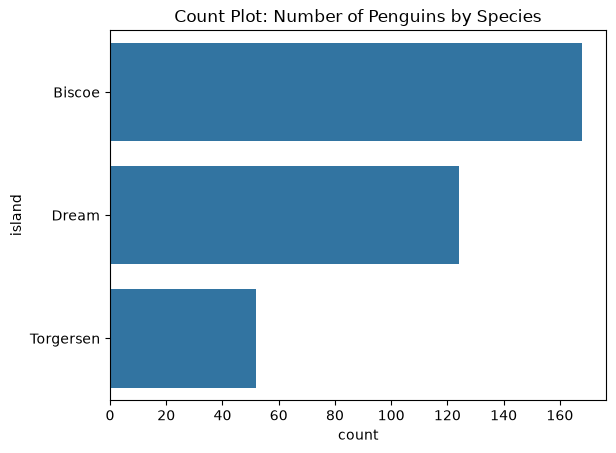

In [16]:
# Count plot: frequency of species
sns.countplot(data=df_penguins, y="island", order=df_penguins["island"].value_counts().index)
plt.title("Count Plot: Number of Penguins by Species")
plt.show()

## Line Plot

Show trends over time 

Required:
- `data = dataframe`: your dataset
- `x = 'fieldname of quantitative'`: quantitative variable for x-axis
- `y = 'fieldname of quantitative'`: quantitative variable for y-axis

Optional:
- `hue = 'fieldname of category'`: adds color grouping for each line. Disables error bars by default.
- `estimator = np.mean`: function to compute the value to be plotted (default is mean)
- `errorbar = ('ci', 95)`: None or a tuple with the confidence interval for the estimate (default is 95%)

The flights dataset has twelve rows per year, one per month. Seaborn silently aggregates them: for each year it computes the median of the twelve monthly values and plots that single point, with the shaded band showing the confidence interval around it.

This is worth noticing, because a line plot given multiple y-values per x will aggregate whether or not you intended it to. If you want every month plotted, give the x-axis something with one row per point.

A line implies the values *between* the points are meaningful, which is why line plots suit time and continuous measures but not categories. There is nothing halfway between "Adelie" and "Gentoo."

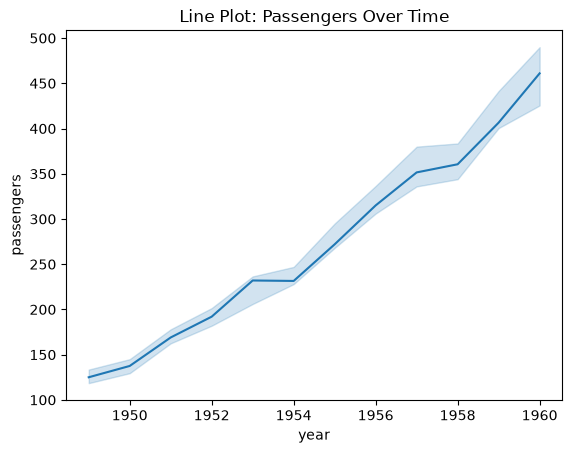

In [17]:
# Lineplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load example dataset
df_flights = sns.load_dataset("flights")

# Line plot showing passengers per year
sns.lineplot(data=df_flights, 
                x="year", y="passengers", 
                errorbar=("ci", 80), 
                estimator=np.median) # or np.mean
plt.title("Line Plot: Passengers Over Time")
plt.show()


## Histogram

Show the distribution of a single quantitative variable.

Required:
- `data = dataframe`: your dataset
- `x = 'fieldname of quantitative'`: the variable to distribute

Optional:
- `bins = 20`: how many intervals to divide the range into
- `kde = True`: overlay a smooth density curve
- `hue = 'fieldname of category'`: draw a separate distribution per group

A histogram slices the range into bins and counts how many rows fall in each. It is the chart that answers the distribution questions from the earlier module: is this normal, uniform, or skewed? Where are the outliers? A histogram works only on quantitative data. For categories, you want the count plot above.

**Bin counts are important.** Too few bins hide structure; too many are noisy. The default is usually reasonable, but always try two or three values before you conclude anything about shape.

As an example, penguin body mass looks bimodal at some bin counts. This can indicate that the dataset mixes species of very different sizes. Splitting by `hue="species"` shows why.


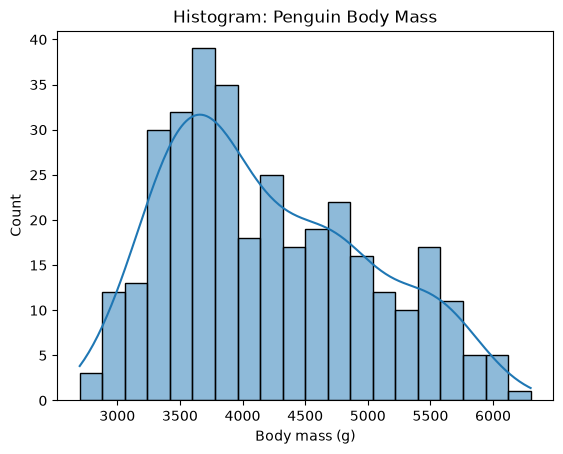

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

sns.histplot(data=df_penguins, x="body_mass_g", bins=20, kde=True)
plt.title("Histogram: Penguin Body Mass")
plt.xlabel("Body mass (g)")
plt.show()

## Scatter Plot

Show  relationship between two quantitative variables.

Required:

- `data = dataframe`: your dataset
- `x = 'fieldname of quantitative'`: quantitative variable for x-axis
- `y = 'fieldname of quantitative'`: quantitative variable for y-axis

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each point.
- `size = 'fieldname of size'`: adds size grouping for each point.


### Four variables on one chart

This chart is doing more than it appears. Position handles two variables, `hue` adds a third, and `size` a fourth. That is about the limit for a casual reader.

`hue` on this particular chart is famous for a reason. Bill length and bill depth look negatively related across all penguins, but positively related *within* each species. Colour by species and the reversal is obvious; leave it out and you would report the opposite of the truth. Whenever a scatter plot looks surprising, try adding a `hue` before believing it.

### alpha and overplotting

`alpha=0.25` makes each point a quarter opaque, so ten overlapping points look darker than one. Without it, a dense region looks identical to a single dot, and you cannot see where the data actually piles up. This is the same **overplotting** problem the earlier module solved with jitter.



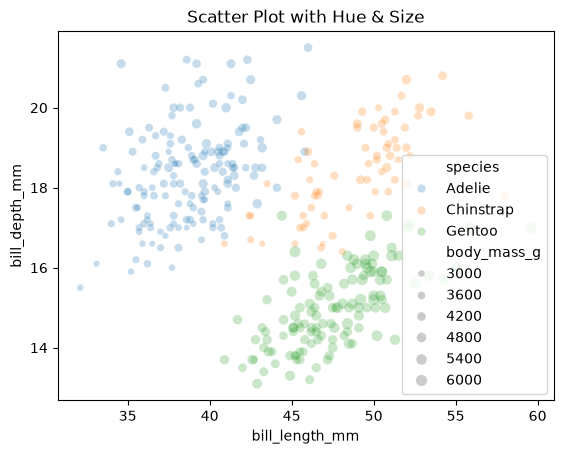

In [19]:
# Scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
df_penguins = sns.load_dataset("penguins")

# Add third variable (species as hue, body_mass as size)
sns.scatterplot(data=df_penguins,
                x="bill_length_mm", y="bill_depth_mm",
                hue="species", 
                size="body_mass_g",
                alpha=0.25)  # very helpful when points overlap, goes from 0 to 1 (transparent to opaque)
plt.title("Scatter Plot with Hue & Size")
plt.show()

## Box Plots 

Show medians, quartiles, and outliers.

Required:
- `data = dataframe`: your dataset
- `x = 'fieldname of category'`: categorical variable
- `y = 'fieldname of quantitative'`: quantitative variable

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each box


Every mark comes from the quartiles in the descriptive statistics module:

- The **box** spans Q1 to Q3 — the middle 50% of the data, the IQR.
- The **line inside the box** is the median, not the mean.
- The **whiskers** reach to the furthest point within 1.5 IQRs of the box.
- The **dots beyond** are outliers by that same 1.5 IQR rule.

So a box plot is that rule drawn to scale. If a value is plotted as an isolated dot, it is exactly what `income[(income < lower) | (income > upper)]` would have returned.

Box plots are ideal for comparisons. Five species side by side let you see instantly which group is higher, which is more variable, and which has strange values.


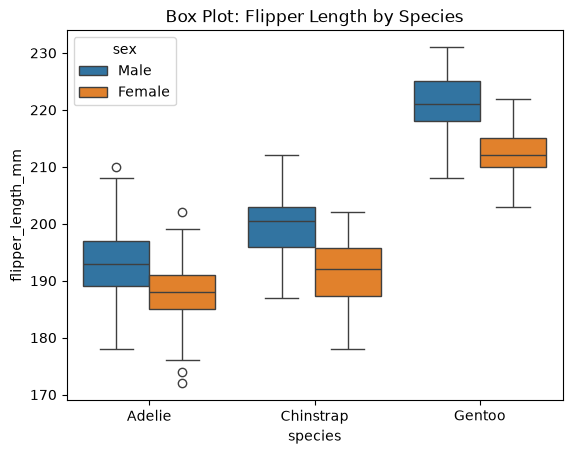

In [20]:
# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Box plot: flipper length across species
sns.boxplot(data=df_penguins, x="species", y="flipper_length_mm", hue="sex")
plt.title("Box Plot: Flipper Length by Species")
plt.show()


## Violin Plots

Similar to boxplot, but shows more detail about distribution shape.

A violin is a box plot with a density curve wrapped around it: the width at any height shows how many observations sit near that value. The violin shows when two groups share median and quartiles while having completely different shapes. A violin with two bulges is bimodal, which usually means a group you have not split out yet.

The cost is that violins need enough data to estimate a smooth curve. With a dozen observations per group, the shape is mostly invention, and a box plot is more honest.

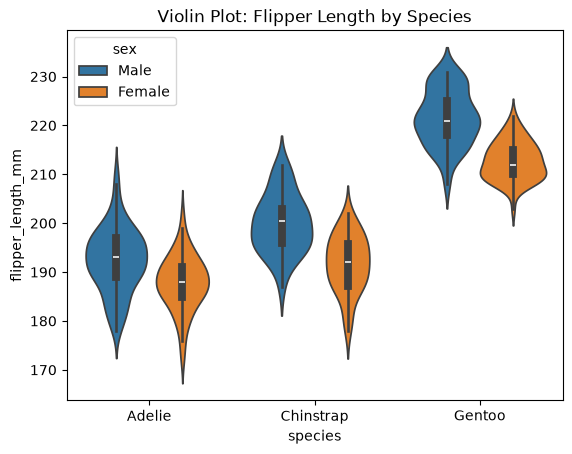

In [21]:
# Violin plot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Violin plot: flipper length across species
sns.violinplot(data=df_penguins, x="species", y="flipper_length_mm", hue="sex")
plt.title("Violin Plot: Flipper Length by Species")
plt.show()

# Pair Plots
Show relationships between all pairs of quantitative variables.
Show relationships between all pairs of quantitative variables.

Required:
- `data = dataframe`: your dataset

Optional:
- `hue = 'fieldname of category'`: adds color grouping for each point
- `kind = 'scatter'`: type of plot to show in the off-diagonal (default is scatter, but can also be 'reg' for regression line, 'kde' for kernel density estimate, etc.)
- `height = 1.5`: size of each subplot in inches — shrink it when you have many variables
- `alpha`: transparency level for points (default is 1, fully opaque). **How you pass it depends on `kind`:**

```python
# With the default kind='scatter', pass alpha directly:
sns.pairplot(data=df, hue='category', plot_kws={'alpha': 0.25})

# With kind='reg', alpha has to be nested inside scatter_kws:
sns.pairplot(data=df, hue='category', kind='reg', plot_kws={'scatter_kws': {'alpha': 0.25}})
```

Passing `plot_kws={'alpha': 0.25}` together with `kind='reg'` raises `TypeError: regplot() got an unexpected keyword argument 'alpha'`, because seaborn hands `plot_kws` straight to the underlying function and `regplot` has no `alpha` parameter of its own.


### Titling a pair plot

Note the `g.figure.suptitle(...)` instead of `plt.title(...)`. A pair plot is a *grid* of subplots, not a single chart, and `plt.title()` attaches its text to whichever subplot was drawn last — the bottom-right cell. Capturing the returned grid as `g` and calling `suptitle` puts the title above the whole figure, where you wanted it. The `y=1.02` nudges it clear of the top row.

Any seaborn function that returns a grid — `pairplot`, `catplot`, `relplot`, `FacetGrid` — behaves this way.

### What to look for

Pair plots are for reconnaissance, not presentation. Scan for:

- **The diagonal** — each variable's own distribution, drawn as a density curve.
- **Tight diagonal bands** in the off-diagonal cells — strongly related variables.
- **Separated colour clusters** — a categorical variable that predicts the numeric ones, which is exactly what you want before a classification model.

A pair plot on twenty variables produces four hundred subplots and tells you nothing. Filter to a handful of columns first.


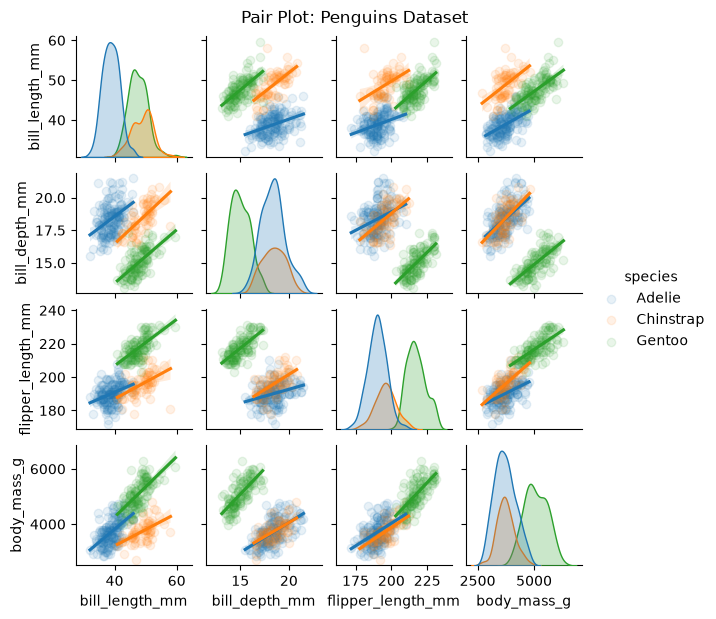

In [22]:
# Pairplot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Pair plot: every pair of numeric columns
g = sns.pairplot(data=df_penguins, 
        hue="species",
        kind="reg",
        height=1.5, 
        plot_kws={'scatter_kws': {'alpha': 0.1}})
g.figure.suptitle("Pair Plot: Penguins Dataset", y=1.02)
plt.show()


## Customizing titles and axis labels

Seaborn labels axes with the column name. `body_mass_g` is fine while you work but not acceptable in a report. Use Matplotlib to fix this problem.

```python
sns.boxplot(data=df_penguins, x="species", y="body_mass_g")

plt.title("Body Mass by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Body mass (grams)")
plt.show()
```

Every call goes **after** the seaborn call and **before** `plt.show()`. `plt.show()` renders and clears the figure, so anything after it applies to a blank canvas — a common reason "my title disappeared."

Sizing, rotation, and saving:

```python
plt.figure(figsize=(10, 4))        # width, height in inches - must come FIRST
sns.countplot(data=df_penguins, x="island")

plt.title("Penguins by Island")
plt.xticks(rotation=45)            # rotate long category labels
plt.savefig("penguins.png", dpi=150, bbox_inches="tight")   # before plt.show()
plt.show()
```

Two ordering rules cover most confusion: `plt.figure()` comes before the chart, everything else comes after it, and `plt.show()` always comes last.

Moving a legend that covers the data:

```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
```

Units belong in the axis label. "Body mass" alone forces the reader to guess whether those numbers are grams, pounds, or kilos.


## Styles and color palettes

`sns.set_theme()` sets the look for every chart that follows, so call it once at the top of your notebook rather than restyling each chart:

```python
sns.set_theme(style="whitegrid", palette="colorblind")
```

The five built-in styles differ in background and gridlines:

```python
sns.set_style("darkgrid")    # the default: grey background, white gridlines
sns.set_style("whitegrid")   # white background, grey gridlines - good for print
sns.set_style("dark")        # grey background, no grid
sns.set_style("white")       # plain white, no grid
sns.set_style("ticks")       # white with axis tick marks
```

Use a grid when readers need to estimate values, and drop it when the shape is the message.

Palettes control the category colours:

```python
sns.countplot(data=df_penguins, x="species", hue="species", palette="colorblind")
```

- **Categorical** (`deep`, `muted`, `pastel`, `colorblind`, `Set2`) — distinct colours for unordered groups.
- **Sequential** (`viridis`, `Blues`, `rocket`) — light-to-dark for ordered or numeric values.
- **Diverging** (`coolwarm`, `vlag`) — two hues from a meaningful midpoint, such as above and below zero.

Match the palette to the data type or you will mislead people: a sequential palette on unordered categories implies a ranking that is not there.

`colorblind` is worth making your default. Roughly 8% of men have some form of colour vision deficiency, and the standard red-green pairing is the one they cannot distinguish. Where it matters, do not rely on colour alone — `hue` plus a different marker shape survives both colour blindness and a black-and-white printout.



## Sample Code

The below code is useful for a quick overview of all variables in a dataset. It creates a plot for each variable. Numbers are shown with a histogram and boxplot, and text with a count plot. Update it by updating `df` to your dataframe of choice.

Three pieces do the work:

- `select_dtypes(include=['number'])` picks the numeric columns; `exclude=['number']` picks everything else. Using `exclude` rather than naming string types is deliberate — pandas has changed how it labels text columns between versions, and `exclude=['number']` behaves the same on all of them.
- `plt.subplot(1, 2, 1)` means "one row, two columns, draw in position 1," which is how the histogram and box plot end up side by side.
- The f-string `f'Histogram of {col}'` inserts the current column name into each title.

Running this on any new dataset takes seconds and answers most of the questions from the descriptive statistics module at once: which variables are skewed, which have outliers, and which categories are rare.

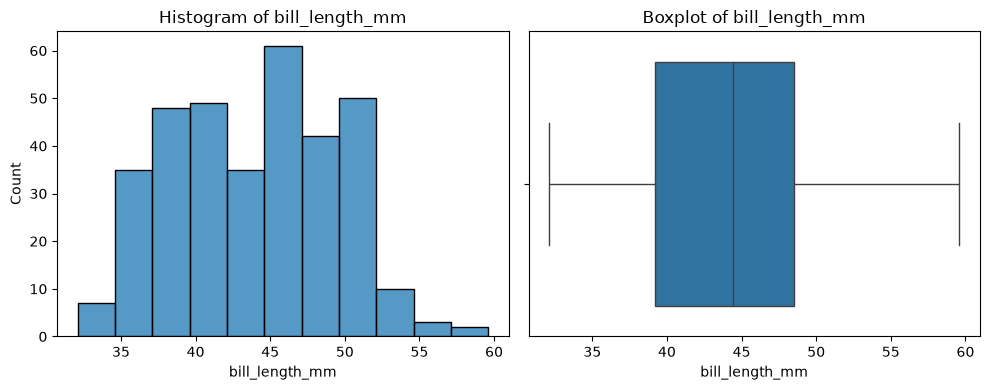

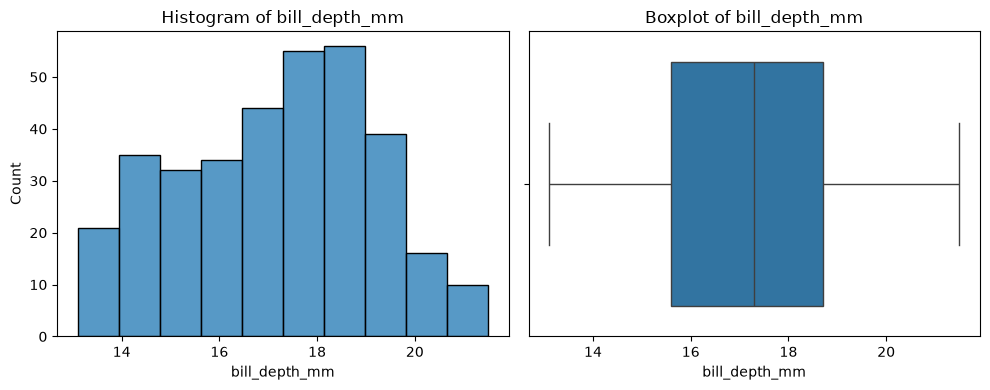

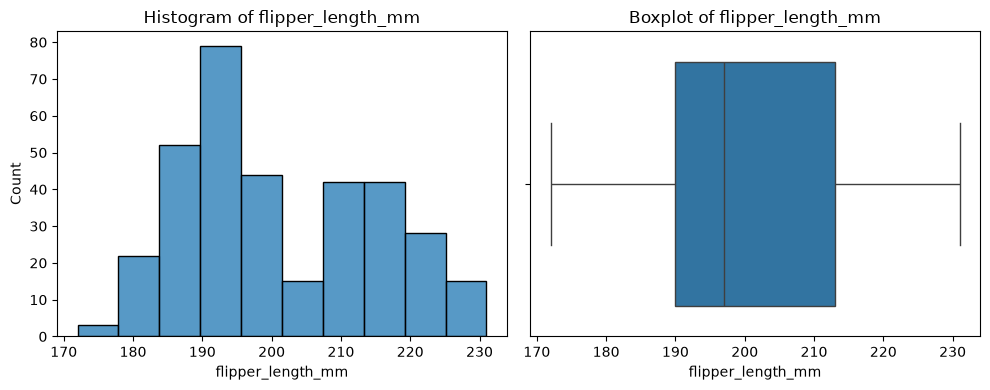

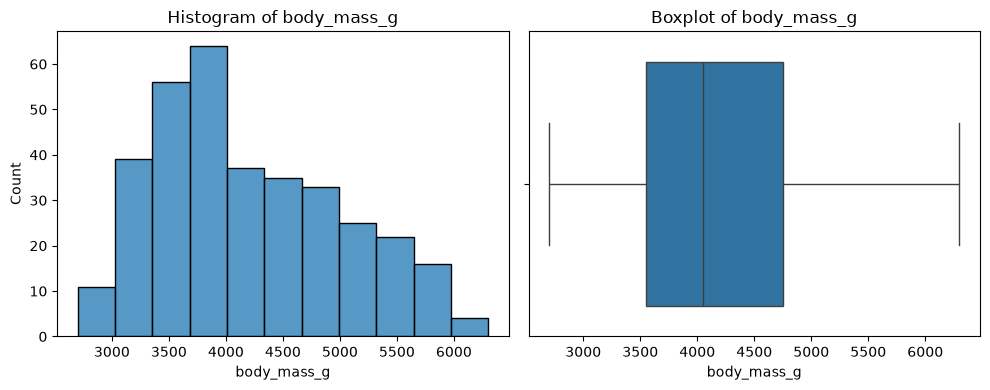

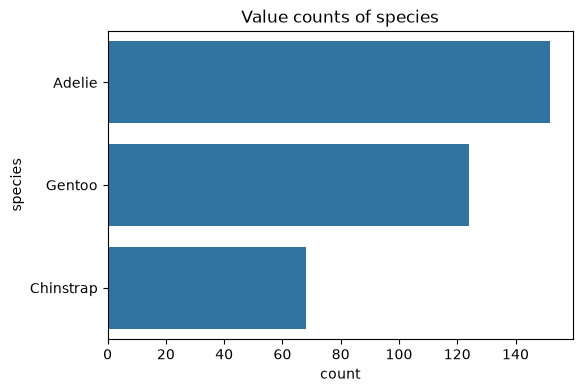

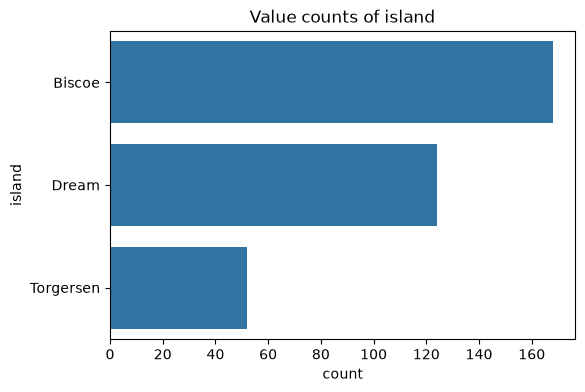

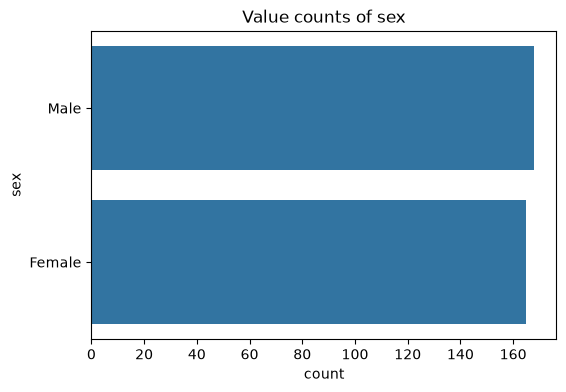

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")

number_columns = df.select_dtypes(include=['number']).columns.tolist()
text_columns = df.select_dtypes(exclude=['number']).columns.tolist()

# Print a histogram and boxplot for each numeric column
for col in number_columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

# Print a chart showing the distribution of values for each text column
for col in text_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Value counts of {col}')
    plt.show()

## Key Terms

- **Seaborn**: A charting library built on Matplotlib, designed to work directly with DataFrames
- **Matplotlib**: The underlying plotting library, used here for titles, labels, and sizing
- **Bar plot**: Compares an aggregate (mean or median) of a quantitative variable across categories
- **Count plot**: Counts how many rows fall in each category
- **Histogram**: Shows the distribution of one quantitative variable using bins
- **Bin**: One of the intervals a histogram divides a variable into
- **Box plot**: Shows median, quartiles, and outliers for a quantitative variable
- **Violin plot**: A box plot plus a density curve showing distribution shape
- **Scatter plot**: Shows the relationship between two quantitative variables
- **Pair plot**: A grid of scatter plots for every pair of quantitative variables
- **hue**: The argument that splits a chart by a categorical variable using color
- **estimator**: The function a bar or line plot uses to aggregate (mean by default)
- **errorbar**: The uncertainty range drawn around an estimate
- **Confidence interval**: The range likely to contain the true value, drawn as the error bar
- **alpha**: Transparency, from 0 (invisible) to 1 (solid), used when points overlap
- **Overplotting**: When points pile on top of each other and hide the true density
- **Style**: Seaborn's preset for background and gridlines
- **Palette**: The set of colors used for categories


## Practice Questions

1. Why does `plt.title()` not work properly on a pair plot?
   - A pair plot is a grid, so the title lands on the last subplot only
   - Pair plots do not support titles
   - The title must be set before the plot is drawn
   - `plt.title` works only on bar plots
1. How do you title a pair plot correctly?
   - Capture the returned grid and call `g.figure.suptitle()`
   - Call `plt.title()` twice
   - Pass `title=` to `sns.pairplot()`
   - Use `plt.xlabel()` instead
1. Which functions set a chart's axis labels?
   - `plt.xlabel()` and `plt.ylabel()`
   - `plt.title()` and `plt.subtitle()`
   - `sns.xlabel()` and `sns.ylabel()`
   - `plt.axis()` alone
1. Where must `plt.title()` be placed?
   - After the seaborn call and before `plt.show()`
   - Before the seaborn call
   - After `plt.show()`
   - Anywhere in the cell
1. Why does a title sometimes fail to appear?
   - It was written after `plt.show()`, which already rendered and cleared the figure
   - Seaborn overrides all Matplotlib titles
   - The title text was too long
   - The figure size was not set
1. Which call changes the figure size, and where does it go?
   - `plt.figure(figsize=(10, 4))`, before the seaborn call
   - `plt.figure(figsize=(10, 4))`, after the seaborn call
   - `sns.set_size(10, 4)`, anywhere
   - `plt.resize(10, 4)`, after `plt.show()`
1. How do you rotate long category labels?
   - `plt.xticks(rotation=45)`
   - `plt.rotate(45)`
   - `sns.set_rotation(45)`
   - `plt.xlabel(rotation=45)`
1. Which function sets the style and palette for every chart that follows?
   - `sns.set_theme()`
   - `sns.style()`
   - `plt.set_defaults()`
   - `sns.palette()`
1. Which style gives a white background with grey gridlines?
   - `whitegrid`
   - `darkgrid`
   - `ticks`
   - `white`
1. Which type of palette suits unordered categories?
   - Categorical, such as `deep` or `colorblind`
   - Sequential, such as `viridis`
   - Diverging, such as `coolwarm`
   - Any of them, since palette type does not matter
1. When should you use a sequential palette such as `viridis`?
   - For ordered or numeric values
   - For unordered categories
   - For values above and below a meaningful midpoint
   - Only for box plots
1. Why prefer the `colorblind` palette?
   - Roughly 8% of men cannot distinguish the standard red-green pairing
   - It uses fewer colors, so charts render faster
   - It is the only palette that works in print
   - It automatically sorts the categories
1. Besides color, what makes a chart readable for colorblind viewers?
   - Also varying marker shape, so color is not the only signal
   - Using more colors
   - Increasing the figure size
   - Removing the legend
1. In the sample code, why use `select_dtypes(exclude=['number'])` for text columns?
   - It works the same across pandas versions, unlike naming the string types
   - It runs faster than `include`
   - It also captures numeric columns with missing values
   - `include` does not accept a list
1. What does `plt.subplot(1, 2, 1)` mean?
   - One row, two columns, draw in the first position
   - One chart, two variables, one axis
   - Draw at coordinates (1, 2, 1)
   - Use bin sizes of 1, 2, and 1